In [1]:
#import sys

#!{sys.executable} -m pip install \
#    "numpy>=2.0,<3" \
#    "pandas>=2.0,<3" \
#    "numba>=0.60" \
#    "scipy>=1.13" \
#    "scikit-learn>=1.4" \
#    "matplotlib>=3.9" \
#    --force-reinstall

#!{sys.executable} -m pip install --upgrade numexpr bottleneck


In [2]:
!pip install feast

In [3]:
import pandas as pd
import numpy as np
print(pd.__version__, np.__version__)

2.3.3 2.4.4


In [4]:
!python helpers/generate_poisson_ar1.py

Simulated DataFrame:
              timestamp  y1  y2
0  2024-01-01T00:00:00Z   4   3
1  2024-01-01T01:00:00Z   6   6
2  2024-01-01T02:00:00Z   2   6
3  2024-01-01T03:00:00Z   1   3
4  2024-01-01T04:00:00Z   3   1
Simulated data saved to 'simulated_poisson_ar1.parquet'


In [5]:
# from raw data to features
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MyApp") \
    .master("local[*]") \
    .getOrCreate()


In [6]:
# read from parquet file
df_sim = spark.read.parquet("simulated_poisson_ar1.parquet")
df_sim.show(5)

+--------------------+---+---+
|           timestamp| y1| y2|
+--------------------+---+---+
|2024-01-01T00:00:00Z|  4|  3|
|2024-01-01T01:00:00Z|  6|  6|
|2024-01-01T02:00:00Z|  2|  6|
|2024-01-01T03:00:00Z|  1|  3|
|2024-01-01T04:00:00Z|  3|  1|
+--------------------+---+---+
only showing top 5 rows



In [7]:
from pyspark.sql import functions as sf
from pyspark.sql.window import Window

# compute lagged values
df_sim = df_sim.withColumn("y1_lag1", sf.lag("y1", 1).over(Window.orderBy("timestamp")))
df_sim = df_sim.withColumn("y2_lag1", sf.lag("y2", 1).over(Window.orderBy("timestamp")))
df_sim.show(3)
df_sim.printSchema()

+--------------------+---+---+-------+-------+
|           timestamp| y1| y2|y1_lag1|y2_lag1|
+--------------------+---+---+-------+-------+
|2024-01-01T00:00:00Z|  4|  3|   NULL|   NULL|
|2024-01-01T01:00:00Z|  6|  6|      4|      3|
|2024-01-01T02:00:00Z|  2|  6|      6|      6|
+--------------------+---+---+-------+-------+
only showing top 3 rows

root
 |-- timestamp: string (nullable = true)
 |-- y1: long (nullable = true)
 |-- y2: long (nullable = true)
 |-- y1_lag1: long (nullable = true)
 |-- y2_lag1: long (nullable = true)



In [8]:
# filter NULL values and save to features.parquet
df_sim_clean = df_sim.filter(sf.col("y1_lag1").isNotNull() & sf.col("y2_lag1").isNotNull())
df_sim_clean.show(3)
df_sim_clean.printSchema()

+--------------------+---+---+-------+-------+
|           timestamp| y1| y2|y1_lag1|y2_lag1|
+--------------------+---+---+-------+-------+
|2024-01-01T01:00:00Z|  6|  6|      4|      3|
|2024-01-01T02:00:00Z|  2|  6|      6|      6|
|2024-01-01T03:00:00Z|  1|  3|      2|      6|
+--------------------+---+---+-------+-------+
only showing top 3 rows

root
 |-- timestamp: string (nullable = true)
 |-- y1: long (nullable = true)
 |-- y2: long (nullable = true)
 |-- y1_lag1: long (nullable = true)
 |-- y2_lag1: long (nullable = true)



In [9]:
# divide in features and labels
df_features = df_sim_clean.select("timestamp", "y1_lag1", "y2_lag1")
df_features.show(3)
df_features.printSchema()

df_label = df_sim_clean.select("timestamp", "y1", "y2")
df_label.show(3)
df_label.printSchema()

+--------------------+-------+-------+
|           timestamp|y1_lag1|y2_lag1|
+--------------------+-------+-------+
|2024-01-01T01:00:00Z|      4|      3|
|2024-01-01T02:00:00Z|      6|      6|
|2024-01-01T03:00:00Z|      2|      6|
+--------------------+-------+-------+
only showing top 3 rows

root
 |-- timestamp: string (nullable = true)
 |-- y1_lag1: long (nullable = true)
 |-- y2_lag1: long (nullable = true)

+--------------------+---+---+
|           timestamp| y1| y2|
+--------------------+---+---+
|2024-01-01T01:00:00Z|  6|  6|
|2024-01-01T02:00:00Z|  2|  6|
|2024-01-01T03:00:00Z|  1|  3|
+--------------------+---+---+
only showing top 3 rows

root
 |-- timestamp: string (nullable = true)
 |-- y1: long (nullable = true)
 |-- y2: long (nullable = true)



In [10]:
from pyspark.sql.functions import regexp_replace, col

# melt features dataframe
df_features_store = df_features.melt(ids=['timestamp'], values=['y1_lag1', 'y2_lag1'],
                                      variableColumnName='entity_id', 
                                      valueColumnName='lag_count')

# replace 'y1_lag', 'y2_lag' with 'y1', 'y2' respectively
df_features_store = df_features_store.withColumn('entity_id', regexp_replace('entity_id', 'y1_lag1', 'y1')) \
                                        .withColumn('entity_id', regexp_replace('entity_id', 'y2_lag1', 'y2'))



# rename column
df_features_store = df_features_store.withColumnRenamed("timestamp", "event_timestamp")

# cast to timestamp
df_features_store = df_features_store.withColumn(
    "event_timestamp", col("event_timestamp").cast("timestamp")
)

df_features_store.show(3)
df_features_store.printSchema()

+-------------------+---------+---------+
|    event_timestamp|entity_id|lag_count|
+-------------------+---------+---------+
|2024-01-01 01:00:00|       y1|        4|
|2024-01-01 01:00:00|       y2|        3|
|2024-01-01 02:00:00|       y1|        6|
+-------------------+---------+---------+
only showing top 3 rows

root
 |-- event_timestamp: timestamp (nullable = true)
 |-- entity_id: string (nullable = false)
 |-- lag_count: long (nullable = true)



In [11]:
# melt label dataframe
df_label_store = df_label.melt(ids=['timestamp'], values=['y1', 'y2'],
                                      variableColumnName='entity_id', 
                                      valueColumnName='target')
# same as for features
df_label_store = df_label_store.withColumnRenamed("timestamp", "event_timestamp")
df_label_store = df_label_store.withColumn(
    "event_timestamp", col("event_timestamp").cast("timestamp")
)
df_label_store.show(3)
df_label_store.printSchema()

+-------------------+---------+------+
|    event_timestamp|entity_id|target|
+-------------------+---------+------+
|2024-01-01 01:00:00|       y1|     6|
|2024-01-01 01:00:00|       y2|     6|
|2024-01-01 02:00:00|       y1|     2|
+-------------------+---------+------+
only showing top 3 rows

root
 |-- event_timestamp: timestamp (nullable = true)
 |-- entity_id: string (nullable = false)
 |-- target: long (nullable = true)



In [12]:
# save both features and label as parquet
df_features_store.select("event_timestamp", "entity_id", "lag_count").write.mode("overwrite").parquet("features.parquet")
df_label_store.select("event_timestamp", "entity_id", "target").write.mode("overwrite").parquet("label.parquet")

In [13]:
from feast import FeatureStore

store = FeatureStore(repo_path="feature_repo/feature_repo")

# load from parquet
entity_df = pd.read_parquet("feature_repo/feature_repo/data/label.parquet")
entity_df = entity_df[entity_df["entity_id"] == "y1"]

In [14]:
TEST_SIZE = 100

# divide in train and test
entity_df_train = entity_df.iloc[:-TEST_SIZE]
entity_df_test = entity_df.iloc[-TEST_SIZE:][["event_timestamp", "entity_id"]]

In [15]:
training_df = store.get_historical_features(
    entity_df=entity_df_train,
    features=[
        "lag_features:lag_count",
    ],
).to_df()

print("length", len(training_df))
print(training_df.tail())

length 199
              event_timestamp entity_id  target  lag_count
194 2024-01-09 03:00:00+00:00        y1       7          4
195 2024-01-09 04:00:00+00:00        y1       4          7
196 2024-01-09 05:00:00+00:00        y1       5          4
197 2024-01-09 06:00:00+00:00        y1       4          5
198 2024-01-09 07:00:00+00:00        y1       1          4


In [16]:
from sklearn import linear_model

poisson_regressor = linear_model.PoissonRegressor(fit_intercept=False)

X = training_df[["lag_count"]].values
y = training_df[["target"]].values

model = poisson_regressor.fit(X, y)
model

/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",False
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",100
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


In [17]:
testing_df = store.get_historical_features(
    entity_df=entity_df_test,
    features=[
        "lag_features:lag_count",
    ],
).to_df()

print("length", len(testing_df))
print(testing_df.head())

# make batch predictions
y_pred = model.predict(testing_df[["lag_count"]].values)

length 100
            event_timestamp entity_id  lag_count
0 2024-01-09 08:00:00+00:00        y1          1
1 2024-01-09 09:00:00+00:00        y1          2
2 2024-01-09 10:00:00+00:00        y1          9
3 2024-01-09 11:00:00+00:00        y1          4
4 2024-01-09 12:00:00+00:00        y1          2


In [18]:
entity_df_test = entity_df.iloc[-TEST_SIZE:].copy()

entity_df_test["prediction"] = y_pred

entity_df_test = entity_df_test.set_index("event_timestamp")

<Axes: xlabel='event_timestamp'>

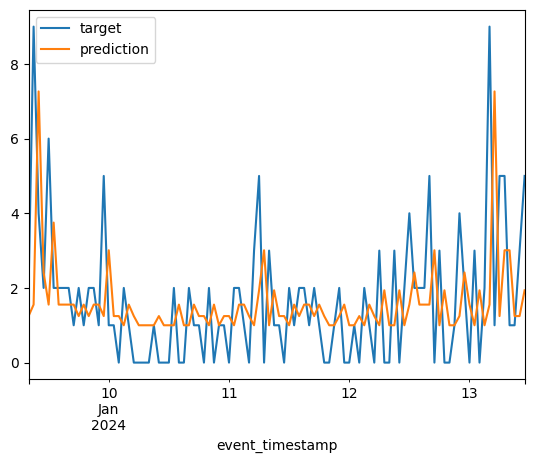

In [ ]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(10, 6))
entity_df_test[["target", "prediction"]].plot()
plt.show()